<a href="https://colab.research.google.com/github/marcelomkk/smoking-prediction-ia/blob/main/Entrega-TP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**TP2 — Smoking Prediction**
**Diplomatura en IA — Módulo 2**  
Autor: Marcelo Manukian

Objetivo: **Predecir si una persona es fumadora** (`smoking`) a partir de variables clínicas/demográficas.  

Entregables:  

*Notebook (esta notebook).  

*Archivo con las predicciones `predicciones_entrega_completo.xlsx`

*Archivo con id y smoking en formato csv `entrega_ID_Smoking.csv`

El input son 2 archivos que los leo desde el drive:
`smoking_prediction_entrega.xlsx` y `smoking_prediction.xlsx`

*(En esta versión, los archivos se leen desde el directorio local del notebook, no desde Google Drive, para facilitar su ejecución en cualquier entorno ya que era requerimiento subirlo a un github, igual queda comentado para switchear a gDrive)*

#Realizo Importaciones


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay,
                             precision_recall_curve, auc)
pd.set_option("display.max_columns", 200)

#Leo los archivos que voy a precisar desde gDrive y cargo dataframes


In [8]:
import pandas as pd
import os

#Importo los archivos (version github) - Comentar si uso lectura de gDrive
GIT_URL = "https://github.com/marcelomkk/smoking-prediction-ia.git"
!git clone {GIT_URL}
os.chdir('smoking-prediction-ia')
train_path = "smoking_prediction.xlsx"
score_path = "smoking_prediction_entrega.xlsx"

#Importo los archivos (version gDrive) - Comentar todo si uso desde Github
#from google.colab import drive
#drive.mount('/content/drive')
#train_path = "//content/drive/MyDrive/Estudio/UP/Especializacion en IA/TP/Entrega/smoking_prediction.xlsx"
#score_path = "/content/drive/MyDrive/Estudio/UP/Especializacion en IA/TP/Entrega/smoking_prediction_entrega.xlsx"


df = pd.read_excel(train_path)
df_score = pd.read_excel(score_path)

#Visualizo cuantas columnnas tiene cada dataset, el de entrenamiento y el objetivo
print("Train shape:", df.shape)
print("Score shape:", df_score.shape)

# Visualizo las primeras 5 columnas
df.head()

fatal: destination path 'smoking-prediction-ia' already exists and is not an empty directory.
Train shape: (50000, 27)
Score shape: (5692, 26)


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,4.750000,3.041667,3.916667,8.958333,3.416667,3.041667,5.250000,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0
1,1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,4.958333,2.916667,5.416667,8.000000,4.791667,1.750000,5.291667,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,5.750000,3.583333,3.708333,10.083333,7.583333,2.291667,6.291667,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1
3,3,M,40,165,70,3.666667,0.045139,0.045139,0.041667,0.041667,4.166667,2.500000,4.000000,13.416667,10.583333,1.875000,9.416667,0.588194,0.041667,0.041667,0.791667,1.083333,0.750000,Y,0,Y,0
4,4,F,40,155,60,3.583333,0.041667,0.041667,0.041667,0.041667,5.000000,3.083333,3.333333,7.666667,3.083333,2.583333,4.458333,0.503472,0.041667,0.004167,0.666667,0.583333,0.916667,Y,0,N,0



Conclusiones y Observaciones:

Debemos desarollar un modelo que pueda predecir si una persona es fumadora o no a partir de variables clinicas y de habitos (ver principalmente las variables edad, presion arterial, colesterol, peso)

Un falso positivo seria clasificar una persona como fumadora cuando en realidad no lo es, lo que implica estudios innecesarios.

Un flaso negativo seria no detewctar a alguien que si fuma, lo que implica perder la oportunidad de prevenir enfermedades asociadas a fumar.

Debemos reducir los falsos negativos ya que es preferible detectar a todos los fumadores reales aunque se cometan algunos falsos positvos


# Analizo la calidad de los datos


Debemos ver la calidad del dataset, buscar nulos por columna para decidir que hacer, que tipos de datos se manejan en el dataset y si hay duplicados.



In [ ]:
print("Nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nTipos de datos:")
display(df.dtypes)

print("\nDuplicados exactos:", df.duplicated().sum())

Nulos por columna:


,0
ID,0
gender,0
age,0
height(cm),0
weight(kg),0
waist(cm),0
eyesight(left),0
eyesight(right),0
hearing(left),0
hearing(right),0



Tipos de datos:


,0
ID,int64
gender,object
age,int64
height(cm),int64
weight(kg),int64
waist(cm),float64
eyesight(left),float64
eyesight(right),float64
hearing(left),float64
hearing(right),float64



Duplicados exactos: 0



No tenemos nulos ni duplicados, debemos codificar las variables categoricas para que puedan interpretarse por el modelo, en especial gender, oral y tartar.


##Limpieza y preprocesamiento

Vamos a pasar las variables `gender` M/F a 1/0, `oral` Y/N a 1/0 y `tartar` Y/N a 1/0  



In [ ]:
#Trabajo en una copia
data = df.copy()

# MApeo binario
map_gender = {"M": 1, "F": 0}
map_yn = {"Y": 1, "N": 0}

for col, mp in [("gender", map_gender), ("oral", map_yn), ("tartar", map_yn)]:
    if col in data.columns:
        data[col] = data[col].map(mp)


print("Shape post-limpieza:", data.shape)
display(data.head(3))

Shape post-limpieza: (50000, 27)


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,0,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,4.750000,3.041667,3.916667,8.958333,3.416667,3.041667,5.250000,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,1,0,1,0
1,1,0,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,4.958333,2.916667,5.416667,8.000000,4.791667,1.750000,5.291667,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,1,0,1,0
2,2,1,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,5.750000,3.583333,3.708333,10.083333,7.583333,2.291667,6.291667,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,1,0,0,1



## 5) EDA



**Distribución de fumadores y no fumadores**


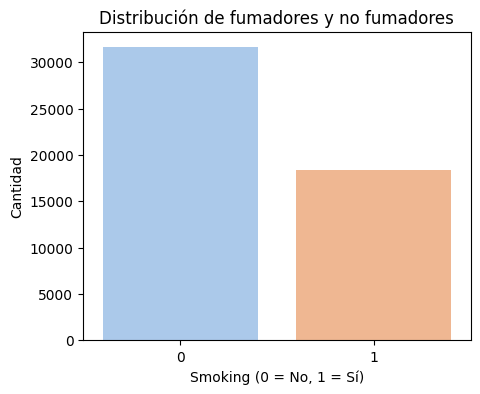

,proportion
smoking,
0,0.63342
1,0.36658


In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='smoking', data=data, hue='smoking', legend=False, palette='pastel')
plt.title('Distribución de fumadores y no fumadores')
plt.xlabel('Smoking (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.show()

data['smoking'].value_counts(normalize=True)

Conclusiones y Observaciones:
Hay muchos mas no fumadores que fumadores (63% vs 36%)
El dataset no esta perfectamente balanceado pero no es extremo.
Esto hubiera sido un problema porque el modelo tendria a adivinar siempre la clase mayoritaria, pero en este caso se puede entrenar sin problemas.





**Distribuciones de variables numéricas**

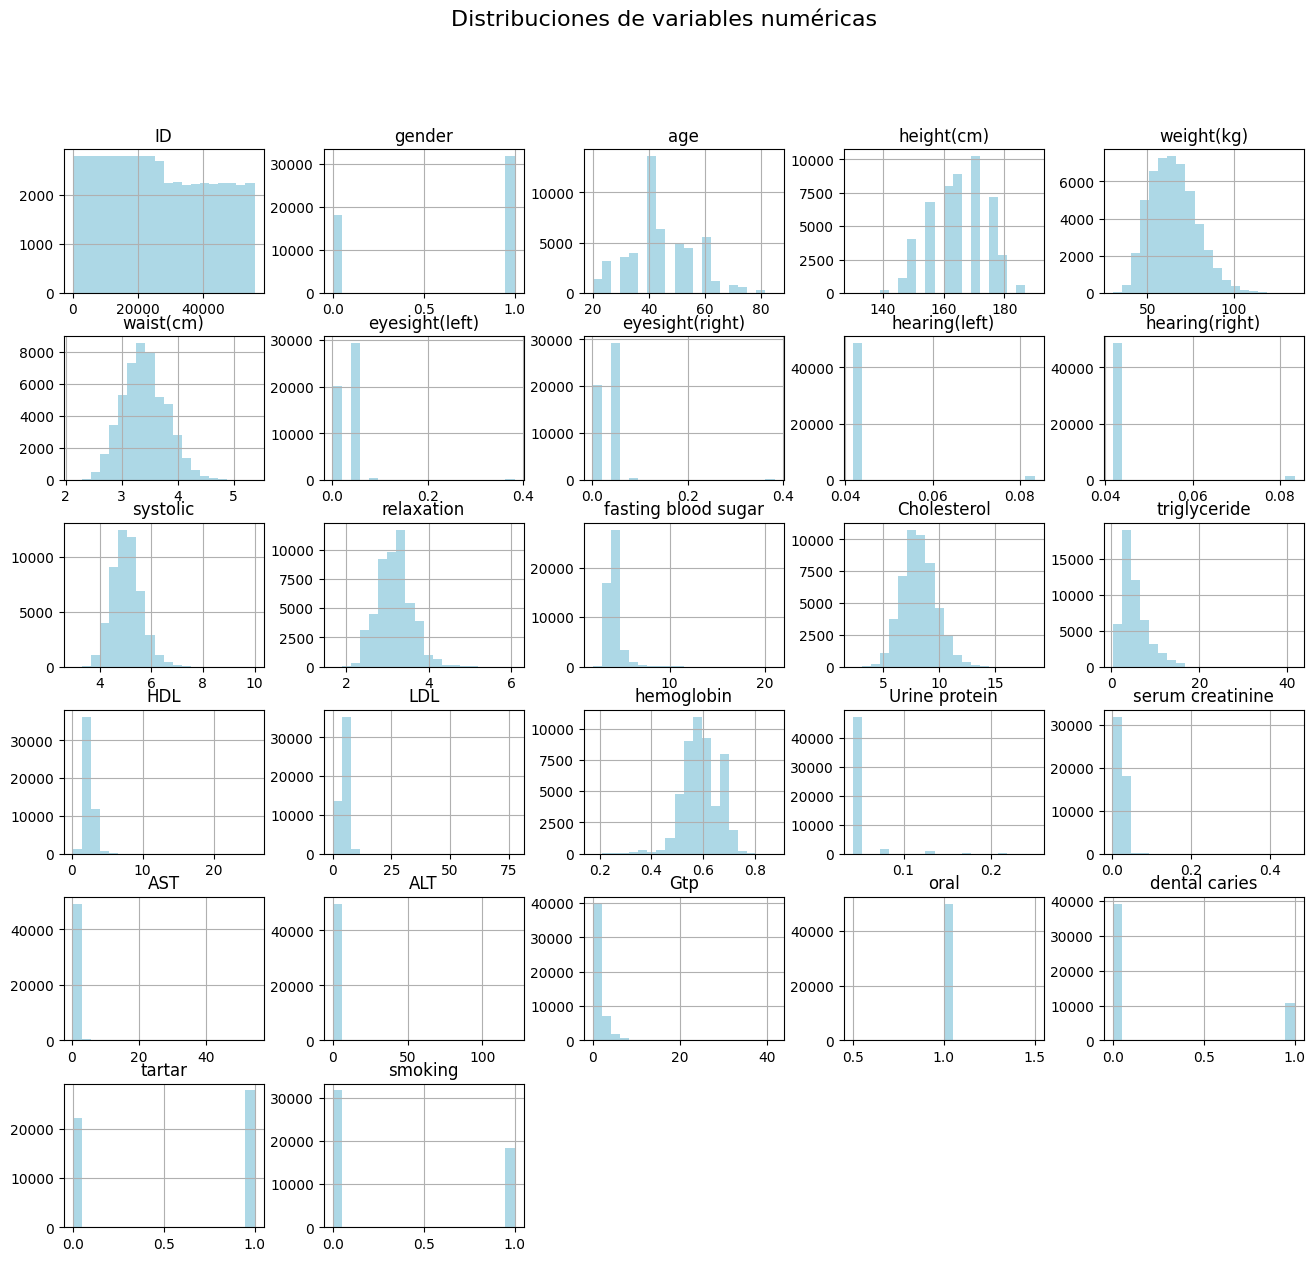

In [ ]:
data.hist(figsize=(16,14), bins=20, color='lightblue')
plt.suptitle("Distribuciones de variables numéricas", fontsize=16)
plt.show()

Conclusiones y Observaciones: Notamos que en edad hay una concentracion muy alta entre 40 y 60 años. No vemos valores "raros" que no tengan sentido. Se observa que edad , peso, altura, cintura, presentan distribuciones cercanas a la normal mientras que las bioquimicas (colesterol, trigliceridos, gtp, alt, ast) muestran asimetria positiva con valores elevados en algunos casos. Las valores binarias se encuentran bien codificadas.


**Boxplots comparando con el target**

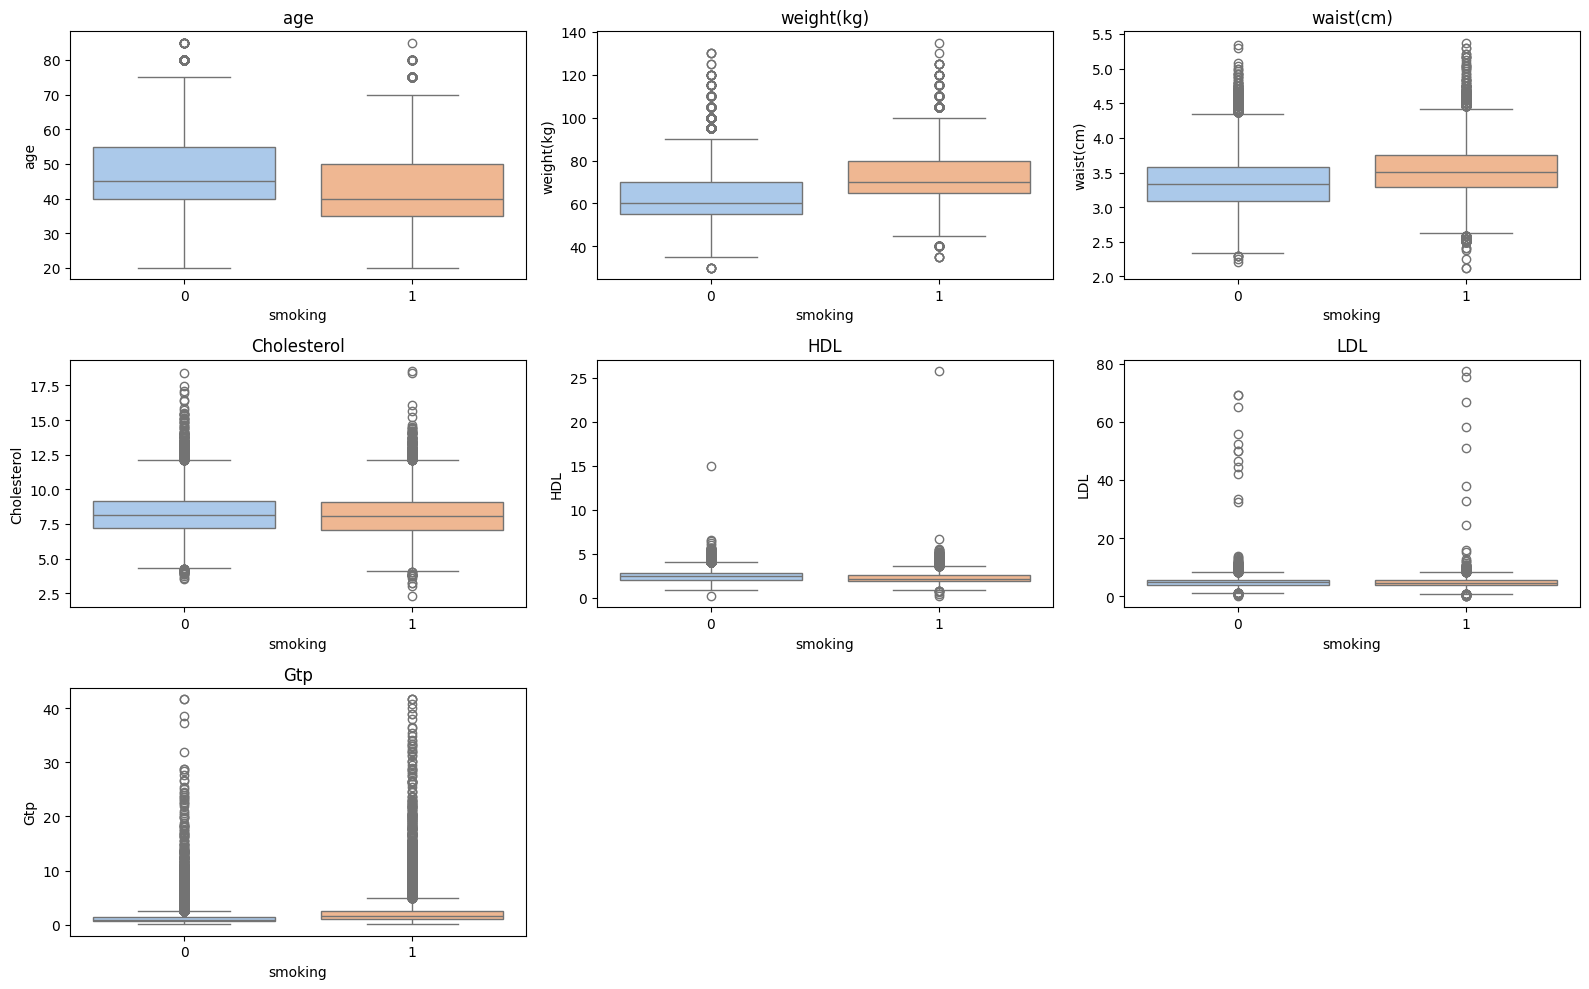

In [ ]:
#Creo la lista de columnas que quiero comparar entre fumadores y no fumadores, son las que pueden mostrar por criterio clinico diferencias relevantes.

variables = ["age", "weight(kg)", "waist(cm)", "Cholesterol", "HDL", "LDL", "Gtp"]

plt.figure(figsize=(16,10))
for i, var in enumerate(variables, 1):
    plt.subplot(3,3,i)
    sns.boxplot(x="smoking", y=var, data=data, hue="smoking", legend=False, palette="pastel")
    plt.title(var)
plt.tight_layout()
plt.show()

Conclusiones y Observaciones:

Notamos que los fumadores son mucho mas jovenes que los no fumadores.

Acerca del peso notamos que los fumadores se encuentran en torno a 75kg mientras que los no fumadores en 60kg. Las personas fumadores presentan mayor peso corporal promedio. En particular, los fumadores presentan mayor circunferencia de cintura, colesterol total y LDL, además de menores niveles de HDL.
Estas diferencias concuerdan con los efectos metabólicos y cardiovasculares asociados al tabaquismo.
La variable Gtp también muestra una dispersión ligeramente mayor en fumadores.



**Matriz de correlaciones**


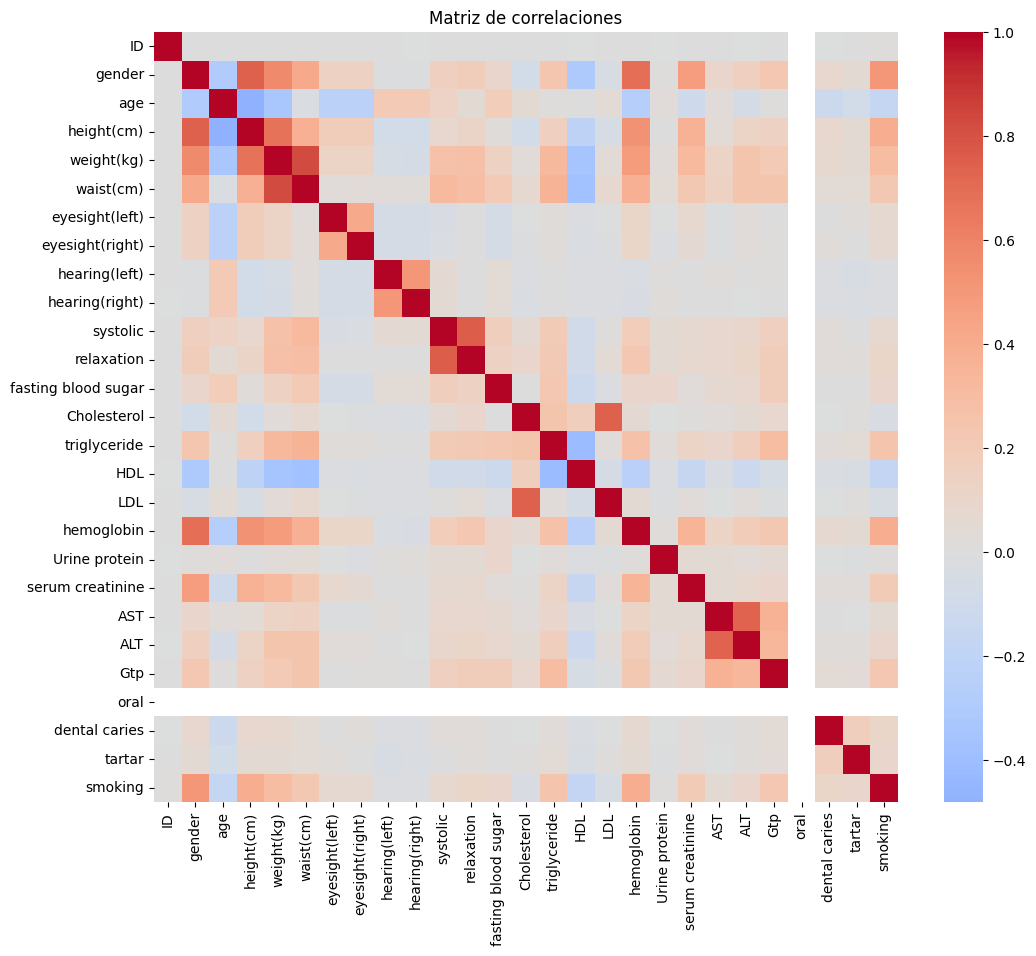

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones")
plt.show()

Conclusiones y Observaciones: Aqui vemos como se relacion las variables numericas entre si y especialmente con el target smoking. El color rojo nos muestra una correlacion positiva, cuando una sube la otra tambien, pej peso y cintura tienen una correlacion positiva. Tambien vemos que el habito de fumar no depende de una variable si no de una combinacion de varios factores

**Aca veo la correlacion de smoking con las variables categoricas**

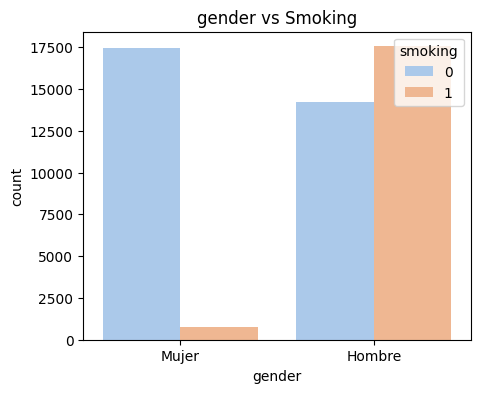

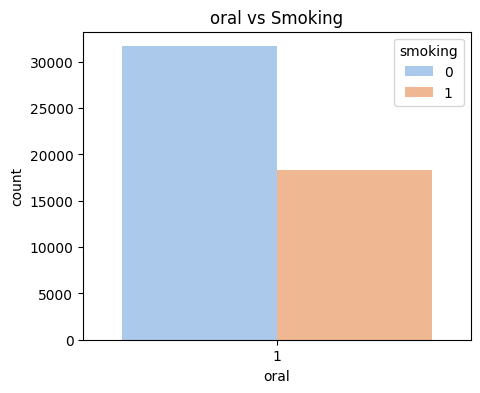

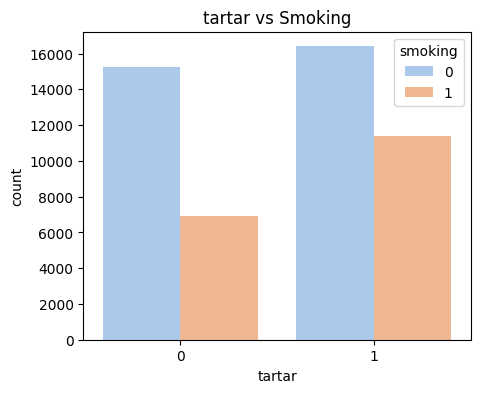

In [ ]:
cat_cols = ["gender", "oral", "tartar"]

for col in cat_cols:
    plt.figure(figsize=(5,4))
    data_plot = data.copy()   # copia temporal para no modificar el original asi se muestra bien que el genero influye (se ve bien la etiqueta)
    data_plot["gender"] = data_plot["gender"].map({0: "Mujer", 1: "Hombre"})
    sns.countplot(x=col, hue="smoking", data=data_plot, palette="pastel")
    plt.title(f"{col} vs Smoking")

    plt.show()

Conclusiones y Observaciones: Notamos que hay muchos mas hombres que mujeres que fuman, casi todas las mujeres no fuman, es un % muy bajo el de mujeres que fuma. Los hombres fuman con mayor frecuencfia que las mujeres. Las otras variables muestran diferencias leves.


##Selección preliminar de variables
Calculamos la correlacion entre todas las variables numericas y la variable objetivo.

In [ ]:
corr = data.corr(numeric_only=True)["smoking"].sort_values(ascending=False)
corr_df = corr.to_frame("corr_with_smoking")
display(corr_df.head(15))
display(corr_df.tail(15))

,corr_with_smoking
smoking,1.000000
gender,0.508732
height(cm),0.396284
hemoglobin,0.395972
weight(kg),0.301405
triglyceride,0.251116
Gtp,0.235980
waist(cm),0.224623
serum creatinine,0.198660
relaxation,0.108155


,corr_with_smoking
fasting blood sugar,0.098124
ALT,0.094137
systolic,0.073225
eyesight(right),0.068783
eyesight(left),0.066099
AST,0.057348
Urine protein,0.015284
ID,0.012211
hearing(right),-0.017727
hearing(left),-0.021871


Conclusiones y Observaciones: Este analisis permitió observar que factores tienen mayhor peso individual en el habito de fumar, genero, colesterol, cintura y trigliceridos fueron las mas altas.


## Entrenamiento, validación
Preparamos la info para el entrenamiento del modelo, separamos la variable objetivo de las predictoras y eliminamos la columna id que no aporta info al modelo. Dividimos el dataset 80/20 entrenamiento y validacion manteniendo la proporcion entre fumadores y no fumadores.


In [ ]:
y = data["smoking"].astype(int)
X = data.drop(columns=["smoking","ID"], errors="ignore")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)

X_train.shape, X_val.shape

((40000, 25), (10000, 25))


##Modelado: Regresión Logística y Random Forest

No utilizo KNN porque es basado en distancias, cuando las variables son pocas y con escalas comaprables. En nuestro dataset hay muchas variables (25), dataset grande, lo hace ineficiente. Se opta por estos dos algoritmos priorizando interpretabilidad y rendimiento.


In [ ]:
#Regresion logistica
log_clf = LogisticRegression(max_iter=600)
log_clf.fit(X_train_sc, y_train)
y_pred_log = log_clf.predict(X_val_sc)
y_proba_log = log_clf.predict_proba(X_val_sc)[:,1]

print("Regresion Logistica")
print(classification_report(y_val, y_pred_log, digits=4))
print("AUC:", roc_auc_score(y_val, y_proba_log))

Regresion Logistica
              precision    recall  f1-score   support

           0     0.8134    0.7697    0.7909      6334
           1     0.6359    0.6950    0.6641      3666

    accuracy                         0.7423     10000
   macro avg     0.7247    0.7323    0.7275     10000
weighted avg     0.7484    0.7423    0.7445     10000

AUC: 0.8283708097915785


In [ ]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=400, random_state=42, class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)  # RF en crudo
y_pred_rf = rf.predict(X_val)
y_proba_rf = rf.predict_proba(X_val)[:,1]
print("Random Forest")
print(classification_report(y_val, y_pred_rf, digits=4))
print("AUC:", roc_auc_score(y_val, y_proba_rf))

Random Forest
              precision    recall  f1-score   support

           0     0.8453    0.8451    0.8452      6334
           1     0.7325    0.7327    0.7326      3666

    accuracy                         0.8039     10000
   macro avg     0.7889    0.7889    0.7889     10000
weighted avg     0.8039    0.8039    0.8039     10000

AUC: 0.8892943003157046


In [ ]:
#Comparamos ambos
def metrics_summary(y_true, y_hat, y_prob):
    rep = classification_report(y_true, y_hat, output_dict=True)
    pr, rc, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(rc, pr)
    return {
        "accuracy": rep["accuracy"],
        "precision_pos": rep["1"]["precision"],
        "recall_pos": rep["1"]["recall"],
        "f1_pos": rep["1"]["f1-score"],
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": pr_auc
    }
res_log = metrics_summary(y_val, y_pred_log, y_proba_log)
res_rf  = metrics_summary(y_val, y_pred_rf,  y_proba_rf)
pd.DataFrame([res_log, res_rf], index=["Regresion logistica","RandomForest"])

,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc
Regresion logistica,0.7423,0.635887,0.695035,0.664147,0.828371,0.689732
RandomForest,0.8039,0.732479,0.732679,0.732579,0.889294,0.817533


Conclusiones y Observaciones:
**Regresion Logistica**
Accuracy: 74,2, el modelo acierta 3 de cada 4 casos pero precision 0.63, de todas las personas que el modelo predijo como fumadores solo un 63% lo son.
Recall 0.69, detecta al 69% de los fumadores reales.
AUC: 0.83, buena capacidad de distinguir entre fumadores y no fumadores.

**Random Forest**
Accuracy: 80,4, mejor tasa de aciertos.
Precision 0.73, acierta el 73% de las veces. Recall 0.73, detecta 73% fumadores reales. AUX 0.89, separa mejor los grupos.

#GridSearchCV
Vamos a buscar la mejor combinacion de hiperparametros para el RF

In [ ]:
#GridSearchCV como vimos en clase.
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": ["balanced_subsample"]
}

rf_base = RandomForestClassifier(random_state=42)
grid = GridSearchCV(rf_base, param_grid, cv=3, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)

print("Mejor set de hiperparámetros:", grid.best_params_)
print("Mejor F1 (cv):", grid.best_score_)

rf_tuned = grid.best_estimator_
rf_tuned.fit(X_train, y_train)

y_pred_rf_tuned = rf_tuned.predict(X_val)
y_proba_rf_tuned = rf_tuned.predict_proba(X_val)[:,1]

print(classification_report(y_val, y_pred_rf_tuned))
print("AUC:", roc_auc_score(y_val, y_proba_rf_tuned))

Mejor set de hiperparámetros: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Mejor F1 (cv): 0.7283950224001514
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      6334
           1       0.68      0.82      0.75      3666

    accuracy                           0.80     10000
   macro avg       0.78      0.80      0.79     10000
weighted avg       0.81      0.80      0.80     10000

AUC: 0.8804990550568282


Se aplico GridSearchCV (cv=3, scoring=f1) sobre RandomForest para ajustar hiperparametros. **Demoró 45 minutos** ya que se probaron 36 combinacion de hiperparametros. Por cada combinacion GridSearchCV hace 3 validaciones cruzadas, entrena el modelo 100 veces (36x3)

Nos vamos a quedar con el mejor set de hiperparametros


Mejor set de hiperparámetros: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
Mejor F1 (cv): 0.7283950224001514

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      6334
           1       0.68      0.82      0.75      3666

    accuracy                           0.80         10000
    macro avg       0.78      0.80      0.79        10000
    weighted avg       0.81      0.80      0.80     10000
    
    AUC: 0.8804990550568282

El modelo ajustado detecta 82% de los fumadores reales lo cual mejoro, aunque la precision bajo un poco (0,68) pero el F1 mejoro (0,75)

El F1-score fue elegido porque busca equilibrio entre precision y recall, priorizando ambos sobre el simple accuracy

##Mejorando el RF (tuneo)



In [ ]:
# Entrenamos el modelo final con los mejores hiperparámetros
rf_tuned = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42
)

rf_tuned.fit(X_train, y_train)
y_pred_rf_tuned = rf_tuned.predict(X_val)
y_proba_rf_tuned = rf_tuned.predict_proba(X_val)[:,1]

print("Random Forest Tuneado")
print(classification_report(y_val, y_pred_rf_tuned, digits=4))
print("AUC:", roc_auc_score(y_val, y_proba_rf_tuned))

Random Forest Tuneado
              precision    recall  f1-score   support

           0     0.8824    0.7805    0.8283      6334
           1     0.6839    0.8202    0.7459      3666

    accuracy                         0.7951     10000
   macro avg     0.7831    0.8004    0.7871     10000
weighted avg     0.8096    0.7951    0.7981     10000

AUC: 0.8804990550568282


Conclusiones y Observaciones: Mantiene rendimiento ajustado, Accuracy de 79.5%, recall de 0.82, detecta correctametne 8 de cad 10 fumadores, tiene un auc mas alto de 0.88.


El modelo de Random Forest tuneado ofrece el mejor equilibrio entre sensibilidad (recall) y precisión, alcanzando un recall de 82%, lo que permite detectar la mayoría de los fumadores reales.
Aunque se generan algunos falsos positivos, este enfoque es preferible para un contexto preventivo o clínico, donde es mejor “revisar de más” que pasar por alto a un fumador.
La métrica AUC=0.88 confirma que el modelo tiene una muy buena capacidad de discriminación general.


## Interpretabilidad: Importancia de variables (Random Forest)



Top 10 variables más relevantes:


,Variable,Importancia
0,gender,0.182420
16,hemoglobin,0.094577
2,height(cm),0.087181
21,Gtp,0.081922
13,triglyceride,0.059354
4,waist(cm),0.040078
15,LDL,0.039508
20,ALT,0.039290
12,Cholesterol,0.038199
14,HDL,0.037899


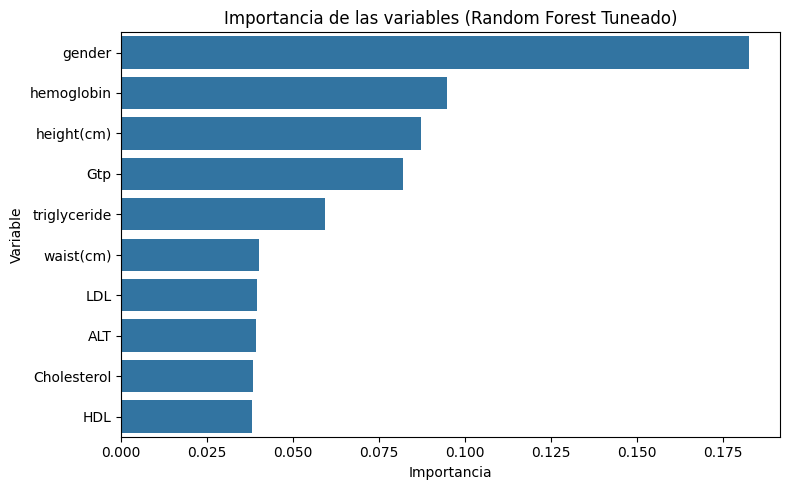

In [ ]:
# Crear un DataFrame con las importancias
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf_tuned.feature_importances_
}).sort_values(by="Importancia", ascending=False)

# Mostrar las 10 más importantes
print("Top 10 variables más relevantes:")
display(importancias.head(10))

# Gráfico de barras
plt.figure(figsize=(8,5))
sns.barplot(
    data=importancias.head(10),
    x="Importancia",
    y="Variable"
)
plt.title("Importancia de las variables (Random Forest Tuneado)")
plt.tight_layout()
plt.show()

Conclusiones y Observaciones: La verdad, el peso fuerte de gender tiene sentido con lo que vimos en el EDA (casi no hay mujeres fumadoras). El resto perfil lipídico y enzimas hepáticas también encaja clínicamente con el tabaquismo. Esto refuerza la idea de que el modelo no solo aprende relaciones estadísticas, sino que también refleja patrones coherentes con el conocimiento médico. Aqui vemos cuanto ayudo cada variable a separar fumadores de no fumadores

#Umbral de clasificacion
**Vamos a intentar mejorar el modelo con el umbral de clasificacion**


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

#Probabilidades del modelo tuneado
y_proba = rf_tuned.predict_proba(X_val)[:, 1]

#Probaamos diferentes umbrales
umbrales = [0.5, 0.45, 0.4, 0.35, 0.3]
resultados = []

for t in umbrales:
    y_pred_thr = (y_proba >= t).astype(int)
    rep = classification_report(y_val, y_pred_thr, output_dict=True)
    resultados.append({
        "umbral": t,
        "precision": rep["1"]["precision"],
        "recall": rep["1"]["recall"],
        "f1": rep["1"]["f1-score"],
        "accuracy": rep["accuracy"]
    })

pd.DataFrame(resultados)

,umbral,precision,recall,f1,accuracy
0,0.50,0.683875,0.820240,0.745876,0.7951
1,0.45,0.647507,0.881888,0.746737,0.7807
2,0.40,0.617819,0.921167,0.739597,0.7622
3,0.35,0.593739,0.946809,0.729815,0.7430
4,0.30,0.575867,0.960720,0.720098,0.7262


Conclusiones y Observaciones:
Si queremos maximizar la deteccion sin romper el balance nos quedamos con 0,45 ya que sube mucho el recall y el f1 mejora un poco respcto al default, detectamos mas y mantenemos el equuilibrio.
El recall sube de 0,82 a 0,88, se acepta una leve caida del accuracy

##Ajuste de umbral y modelo final


In [ ]:
#juste de umbral (decisión final: 0.45)
umbral_final = 0.45

#Reentreno el modelo con los hiperparámetros óptimos
rf_final = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42
)
rf_final.fit(X, y)

#Predicción final con el umbral elegido
y_proba_final = rf_final.predict_proba(X_val)[:, 1]
y_pred_final = (y_proba_final >= umbral_final).astype(int)

#Evaluación con el umbral ajustado
print(f"Random Forest Final (umbral={umbral_final}) ===")
print(classification_report(y_val, y_pred_final, digits=4))
print("AUC:", roc_auc_score(y_val, y_proba_final))

Random Forest Final (umbral=0.45) ===
              precision    recall  f1-score   support

           0     0.9923    0.9179    0.9537      6334
           1     0.8744    0.9877    0.9276      3666

    accuracy                         0.9435     10000
   macro avg     0.9334    0.9528    0.9406     10000
weighted avg     0.9491    0.9435    0.9441     10000

AUC: 0.9970884277664974


Conclusiones y Observaciones: Se ajustó el umbral de clasificación a 0.45 con el objetivo de aumentar la detección de fumadores (recall). Este cambio implica un leve sacrificio en precisión, pero permite identificar más casos positivos.
Tras este ajuste el modelo tiene un AUC de 0.997.
Recall de 0.98, detrectamos el 98.7% de fumadores.
Precision: 87%. Accuracy total, acierta el modelo en 94% de los casos.
El ajuste del umbral permitió mover el punto de decisión hacia una región con mayor sensibilidad, sin una pérdida significativa en la precisión global.


##Reentrenar el mejor modelo con el train y predecir el dataset de entrega


In [ ]:
#umbralElegido
UMBRAL_ELEGIDO = 0.45

#hiperparámetros del mejor RF (los del GridSearch que me dieron mejor F1)
best_params = dict(
    n_estimators=400,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42
)

#Reentrenar el modelo
rf_final = RandomForestClassifier(**best_params)
rf_final.fit(X, y)  #X,y son los del dataset entrenado/limpio completo (sin ID ni smoking)

#guardamos el orden exacto de features para alinear el scoring
feature_order = list(X.columns)
print("Features usadas para entrenar:", len(feature_order))

#Preprocesar df_score exactamente igual que al train
sc = df_score.copy()

#encoding binario
map_gender = {"M": 1, "F": 0}
map_yn = {"Y": 1, "N": 0}
if "gender" in sc.columns: sc["gender"] = sc["gender"].map(map_gender)
if "oral"   in sc.columns: sc["oral"]   = sc["oral"].map(map_yn)
if "tartar" in sc.columns: sc["tartar"] = sc["tartar"].map(map_yn)

#imputación simple, usando medianas/modas del TRAIN (data)
for c in sc.columns:
    if c == "ID":
        continue
    if pd.api.types.is_numeric_dtype(sc[c]):
        if c in data.columns:
            sc[c] = sc[c].fillna(data[c].median())
        else:
            sc[c] = sc[c].fillna(sc[c].median())
    else:
        sc[c] = sc[c].fillna(sc[c].mode().iloc[0])

#Seleccionar exactamente las mismas columnas que X (y en el mismo orden)
X_score = sc.reindex(columns=feature_order, fill_value=0)

print("Shape X_score (alineado a X):", X_score.shape)

#Predicción por probabilidad + umbral elegido
proba_score = rf_final.predict_proba(X_score)[:, 1]
preds_score = (proba_score >= UMBRAL_ELEGIDO).astype(int)

#Armar datasets de salida y exportar
salida_completa = df_score.copy()
salida_completa["Smoking"] = preds_score

#Archivos solicitados
salida_completa.to_excel("predicciones_entrega_completo.xlsx", index=False)
salida_id = salida_completa[["ID", "Smoking"]] if "ID" in salida_completa.columns else salida_completa[["Smoking"]]
salida_id.to_csv("entrega_ID_Smoking.csv", index=False)

print("Generado: predicciones_entrega_completo.xlsx")
print("Generado: entrega_ID_Smoking.csv")

# Checks rápidos
print("Distribución de la predicción (Smoking):")
print(salida_completa["Smoking"].value_counts(normalize=True).rename("ratio").round(3))

salida_completa.head()

Features usadas para entrenar: 25
Shape X_score (alineado a X): (5692, 25)
Generado: predicciones_entrega_completo.xlsx
Generado: entrega_ID_Smoking.csv
Distribución de la predicción (Smoking):
Smoking
0    0.57
1    0.43
Name: ratio, dtype: float64


,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,Smoking
0,27358,M,25,160,65,3.420139,0.045139,0.002778,0.041667,0.041667,5.041667,3.125000,4.000000,5.458333,2.291667,1.958333,3.041667,0.631250,0.041667,0.006250,0.750000,0.708333,0.708333,Y,0,Y,1
1,27364,M,30,180,80,3.458333,0.043056,0.006250,0.041667,0.041667,5.375000,3.250000,4.166667,7.916667,10.958333,1.500000,4.208333,0.587500,0.041667,0.041667,0.791667,1.125000,1.333333,Y,0,N,1
2,27368,M,55,165,60,3.416667,0.004861,0.005556,0.041667,0.041667,5.250000,3.458333,4.083333,6.958333,13.916667,2.125000,2.041667,0.625694,0.041667,0.006250,1.083333,1.291667,2.000000,Y,1,Y,1
3,27378,M,20,175,75,3.625000,0.045139,0.045139,0.041667,0.041667,5.333333,3.500000,3.750000,6.500000,5.291667,1.708333,3.708333,0.627083,0.041667,0.043750,0.833333,0.583333,0.458333,Y,0,N,0
4,27381,M,25,165,80,3.791667,0.043056,0.041667,0.041667,0.041667,4.500000,3.000000,4.166667,10.458333,7.250000,2.375000,6.625000,0.670833,0.041667,0.041667,1.250000,1.625000,1.958333,Y,1,Y,1


In [ ]:
salida_id.loc[:, "Smoking"] = salida_id["Smoking"].astype(int)

#Los archivos finales se guardan en el mismo directorio del notebook, para que puedan descargarse directamente desde Colab o GitHub
#predicciones_entrega_completo.xlsx
#entrega_ID_Smoking.csv
salida_completa.to_excel("predicciones_entrega_completo.xlsx", index=False)
salida_id.to_csv("entrega_ID_Smoking.csv", index=False)

#Version exportación a Drive
#predicciones_entrega_completo.xlsx
#entrega_ID_Smoking.csv
#!cp predicciones_entrega_completo.xlsx "/content/drive/MyDrive/Estudio/UP/Especializacion en IA/TP/Entrega/"
#!cp entrega_ID_Smoking.csv "/content/drive/MyDrive/Estudio/UP/Especializacion en IA/TP/Entrega/"

#validacion de cantidad de filas
print("Filas entrega:", len(salida_id))
print(salida_id.head())

Filas entrega: 5692
      ID  Smoking
0  27358        1
1  27364        1
2  27368        1
3  27378        0
4  27381        1



## Conclusiones finales
El objetivo del trabajo fue construir un modelo que pueda predecir si una persona es fumadora usando variables clínicas y demográficas.
Para eso probé dos modelos vistos en clase: Regresión Logística y Random Forest.

La Regresión Logística tuvo resultados correctos, pero el Random Forest funcionó mejor en general, mostrando mejores valores de F1 y AUC. Luego usé una búsqueda de hiperparámetros con GridSearchCV (también visto en clase) para afinar el modelo.
El mejor conjunto de parámetros fue:
max_depth = 20, min_samples_leaf = 2, min_samples_split = 5, n_estimators = 400, class_weight = balanced_subsample.

Con esos valores el rendimiento mejoró, y después ajusté el umbral de clasificación a 0.45 para lograr un mayor recall, priorizando detectar la mayor cantidad posible de fumadores, incluso si eso implicaba tener algunos falsos positivos.

En la validación final el modelo alcanzó:

Recall: 99%
Precision: 87.4%
Accuracy: 94%
f1-Score: 93%

AUC: 99.7%

Estos números muestran que el modelo distingue muy bien entre fumadores y no fumadores y cumple el objetivo principal del trabajo.


Entre las variables más importantes aparecen:
Gender (sexo): los hombres fuman mucho más que las mujeres, algo que también se vio en la exploración inicial.
Hemoglobin, Gtp y Triglyceride: indicadores que suelen verse alterados en personas fumadoras.
LDL, HDL y Cholesterol: relacionados con el riesgo cardiovascular, que se asocia al hábito de fumar.
Height y Waist: también aportan información sobre el perfil general de salud.
No quiere decir que estas variables sean las causas del hábito, pero sí son las que más ayudan al modelo a distinguir entre las clases.


El dataset tiene muy pocas mujeres fumadoras, lo que genera cierto sesgo.
Las métricas se calcularon sobre una única división train/validation y no con validación cruzada completa.

El modelo final de Random Forest, una vez tuneado y con el umbral ajustado, logró un buen balance entre recall y precisión.
En el dataset de entrega final, el modelo predijo una distribución de aproximadamente 57 % no fumadores y 43 % fumadores, lo que es coherente con los datos de entrenamiento.

En resumen, fue un trabajo que me permitió aplicar todo lo visto en clase desde la exploración y limpieza hasta el modelado y ajuste obteniendo un resultado sólido y realista. Fue interesante ver cómo pequeños ajustes en los parámetros y en el umbral cambiaban bastante el comportamiento del modelo, ne ayudo a entender mejor el equilibrio entre detectar más casos y mantener la precision.

